In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as m
import seaborn as sns
import scipy
from scipy.stats import boxcox
import holidays
import datetime
import xgboost as xgb
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [87]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

statsmodels: 0.14.2
matplotlib : 3.9.2
seaborn    : 0.13.2
holidays   : 0.74
pandas     : 2.2.2
scipy      : 1.13.1
sklearn    : 1.5.1
xgboost    : 3.0.2
numpy      : 1.26.4



In [88]:
dados = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Análise e Previsão de Séries Temporais/Dados/dataset.csv")

In [89]:
plt.style.use('fivethirtyeight')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
m.rcParams['axes.labelsize'] = 14
m.rcParams['xtick.labelsize'] = 12
m.rcParams['ytick.labelsize'] = 12
m.rcParams['text.color'] = 'k'

In [90]:
dados.head()

,2004-01,112
0,2004-02,118
1,2004-03,132
2,2004-04,129
3,2004-05,121
4,2004-06,135


In [91]:
dados.columns = ['mes', 'consumo_energia']

In [92]:
dados.head()

,mes,consumo_energia
0,2004-02,118
1,2004-03,132
2,2004-04,129
3,2004-05,121
4,2004-06,135


In [93]:
dados.describe()

,consumo_energia
count,143.000000
mean,281.489510
std,119.537952
min,104.000000
25%,180.500000
50%,267.000000
75%,361.000000
max,622.000000


In [94]:
dados.shape

(143, 2)

In [95]:
dados['mes'] = pd.to_datetime(dados['mes'], format = '%Y-%m')

In [96]:
dados.head()

,mes,consumo_energia
0,2004-02-01,118
1,2004-03-01,132
2,2004-04-01,129
3,2004-05-01,121
4,2004-06-01,135


In [97]:
dados_serie = dados.set_index('mes')

In [98]:
dados_serie.head()

,consumo_energia
mes,
2004-02-01,118
2004-03-01,132
2004-04-01,129
2004-05-01,121
2004-06-01,135


In [99]:
dados_serie.isnull().sum()

consumo_energia    0
dtype: int64

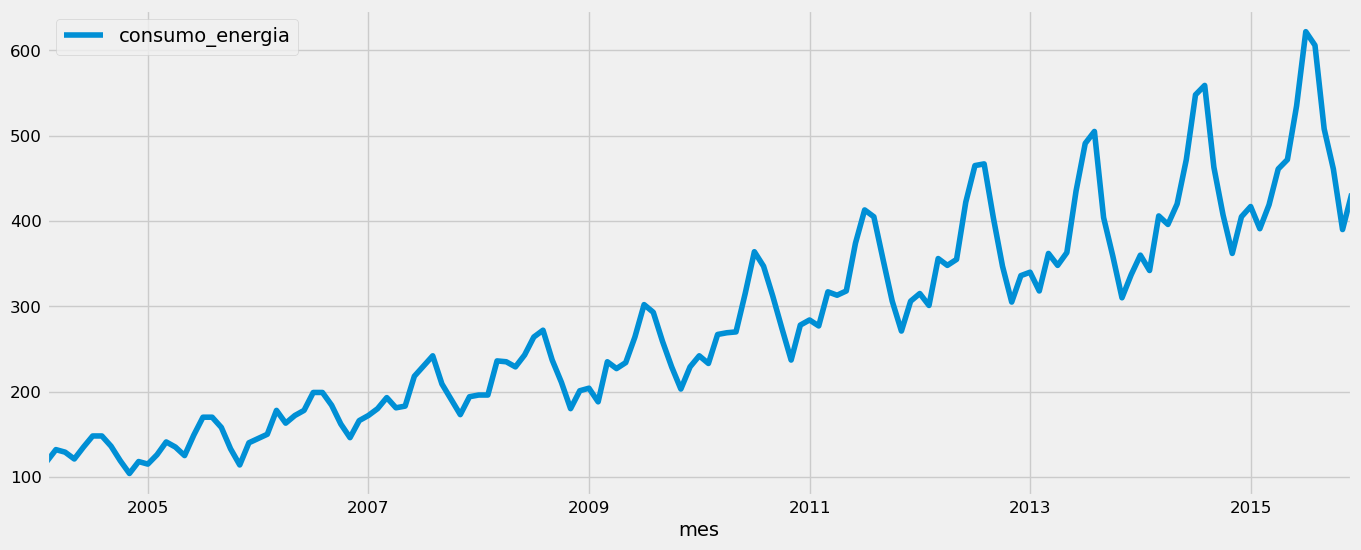

In [100]:
dados_serie.plot(figsize = (15, 6))
plt.show()

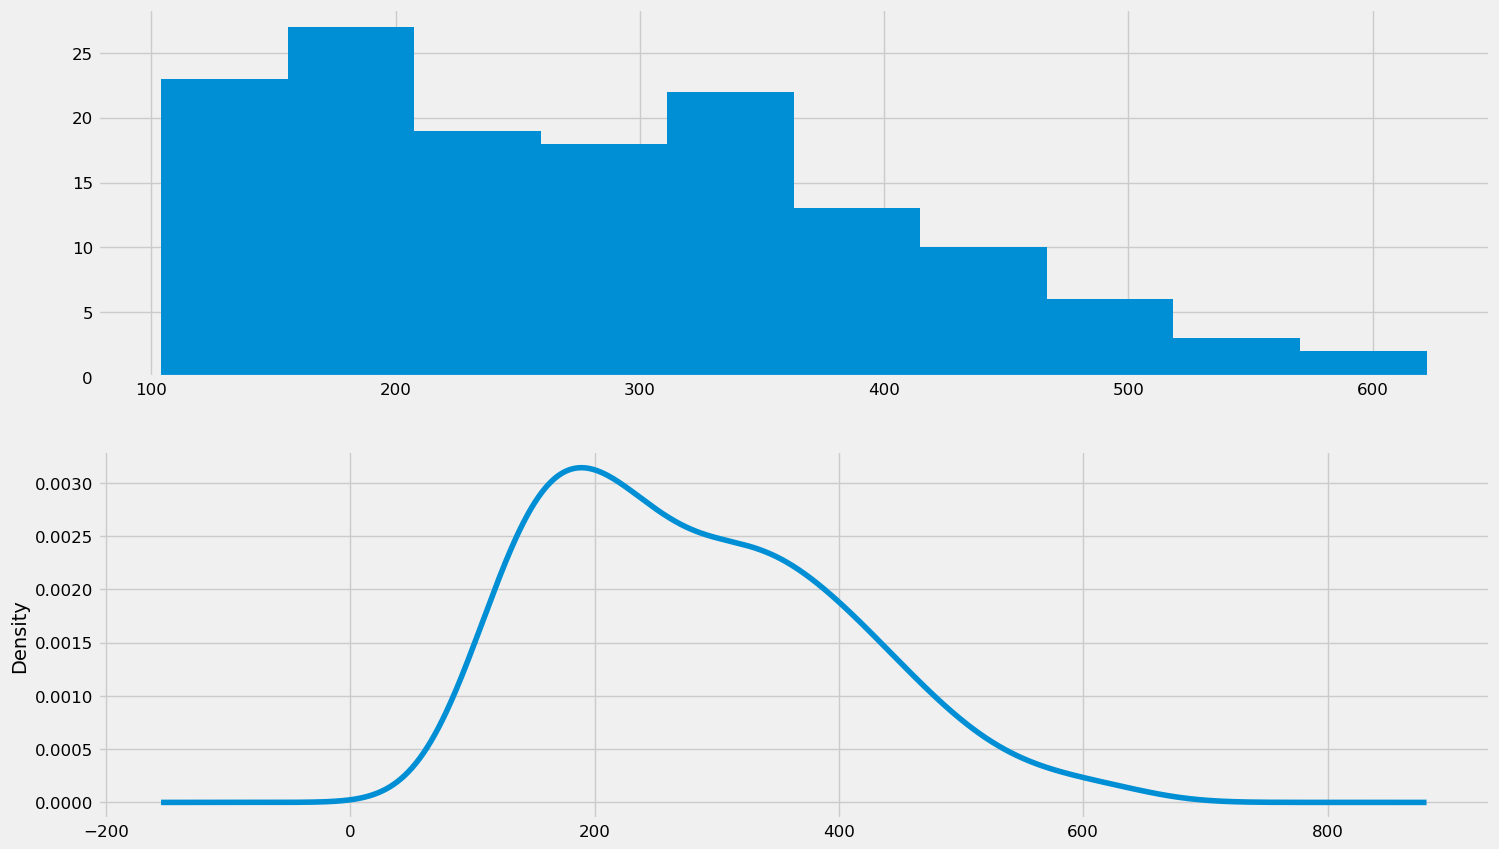

In [101]:
plt.figure(1)

plt.subplot(211)
dados_serie.consumo_energia.hist()

plt.subplot(212)
dados_serie.consumo_energia.plot(kind = 'kde')
plt.show()

Text(0, 0.5, '/nConsumo de Energia')

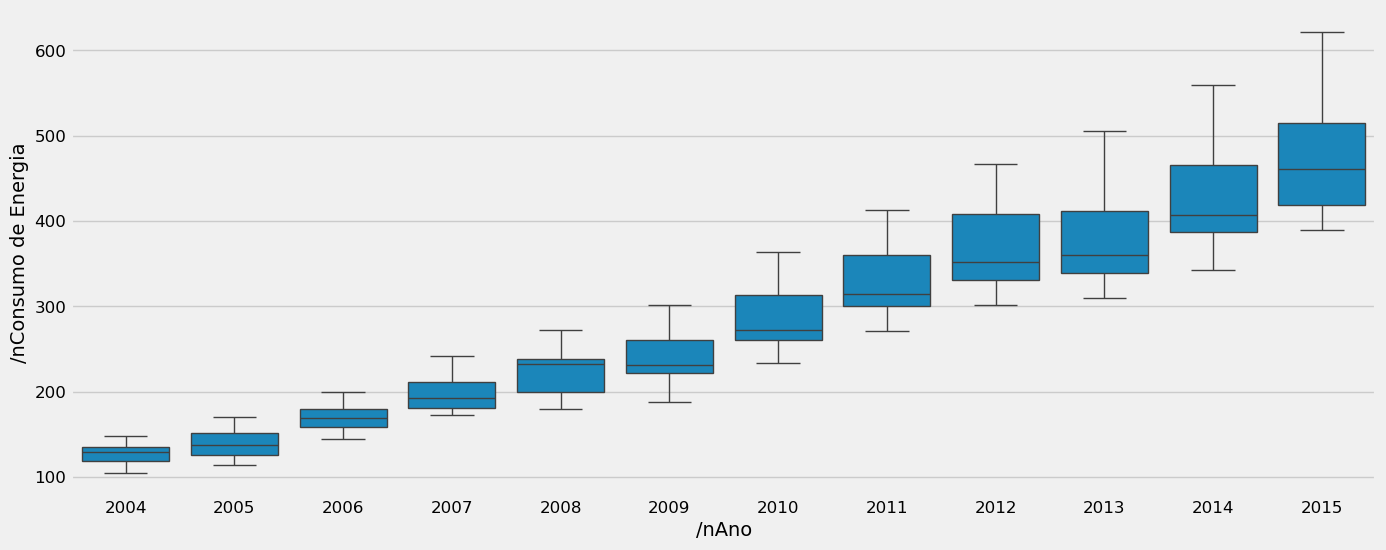

In [102]:
fig, ax = plt.subplots(figsize = (15, 6))

indice_ano = dados_serie.consumo_energia.index.year
valor = dados_serie.consumo_energia

sns.boxplot(x = indice_ano, y = valor, ax = ax, data = dados_serie)

plt.xlabel("/nAno")
plt.ylabel("/nConsumo de Energia")

In [103]:
decomposicao_multiplicativa = sm.tsa.seasonal_decompose(dados_serie, 
                                                        model = 'multiplicative', 
                                                        extrapolate_trend = 'freq')


In [104]:
decomposicao_aditiva = sm.tsa.seasonal_decompose(dados_serie,
                                                  model = 'aditive',
                                                  extrapolate_trend = 'freq')

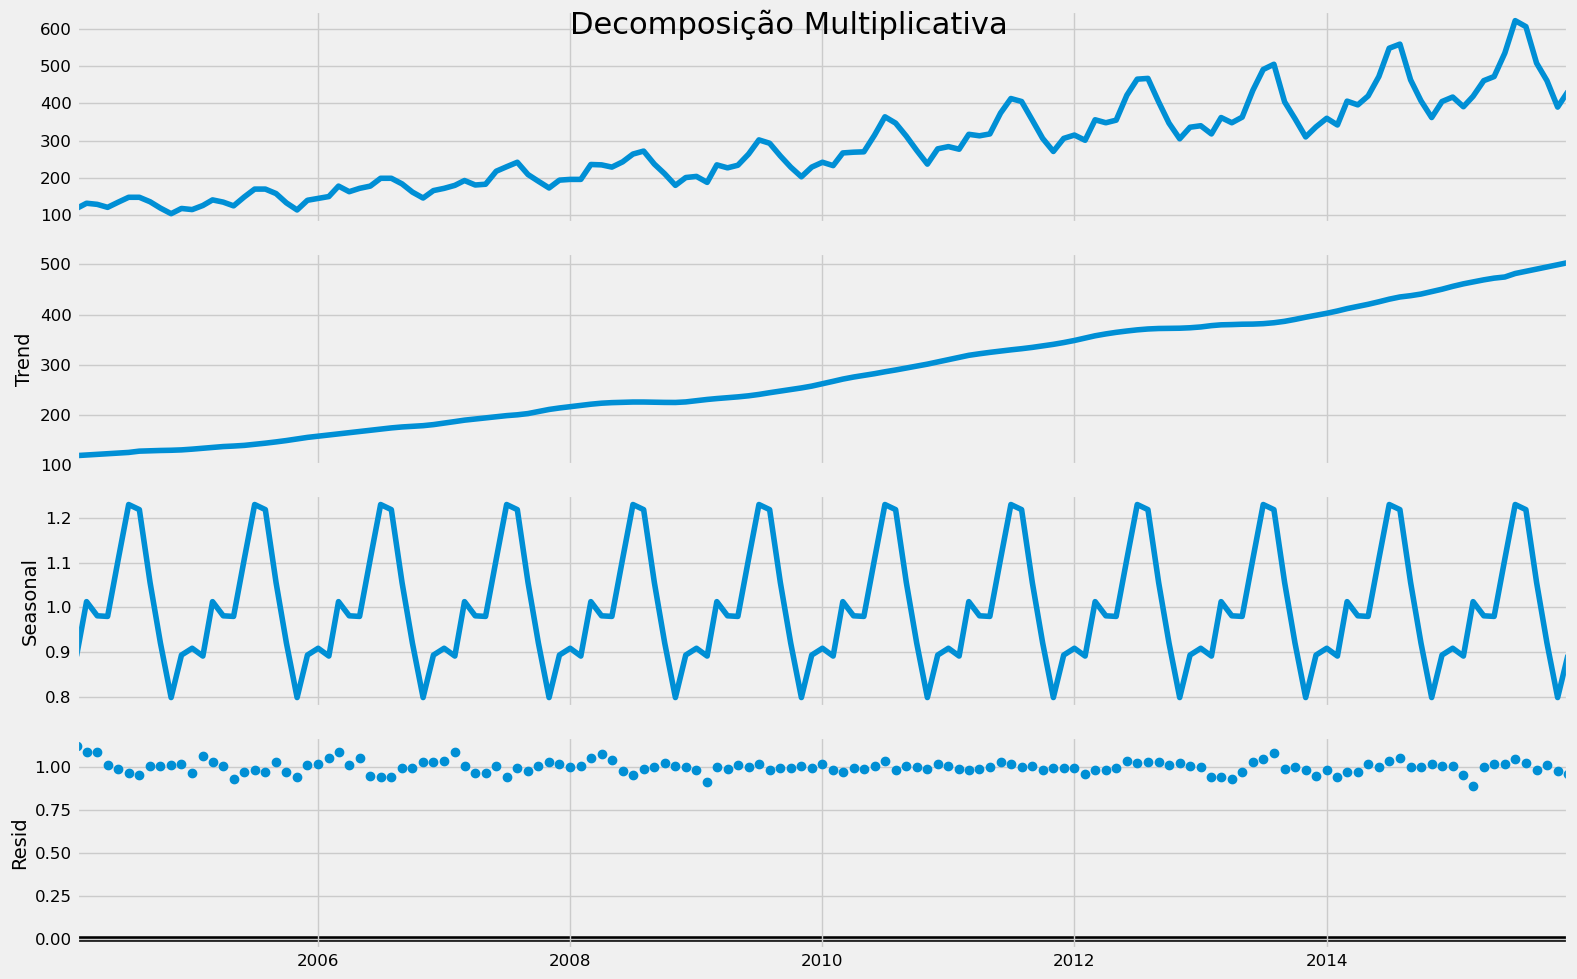

In [105]:
plt.rcParams.update({'figure.figsize': (16, 10)})
decomposicao_multiplicativa.plot().suptitle('Decomposição Multiplicativa', fontsize = 22)
plt.show()

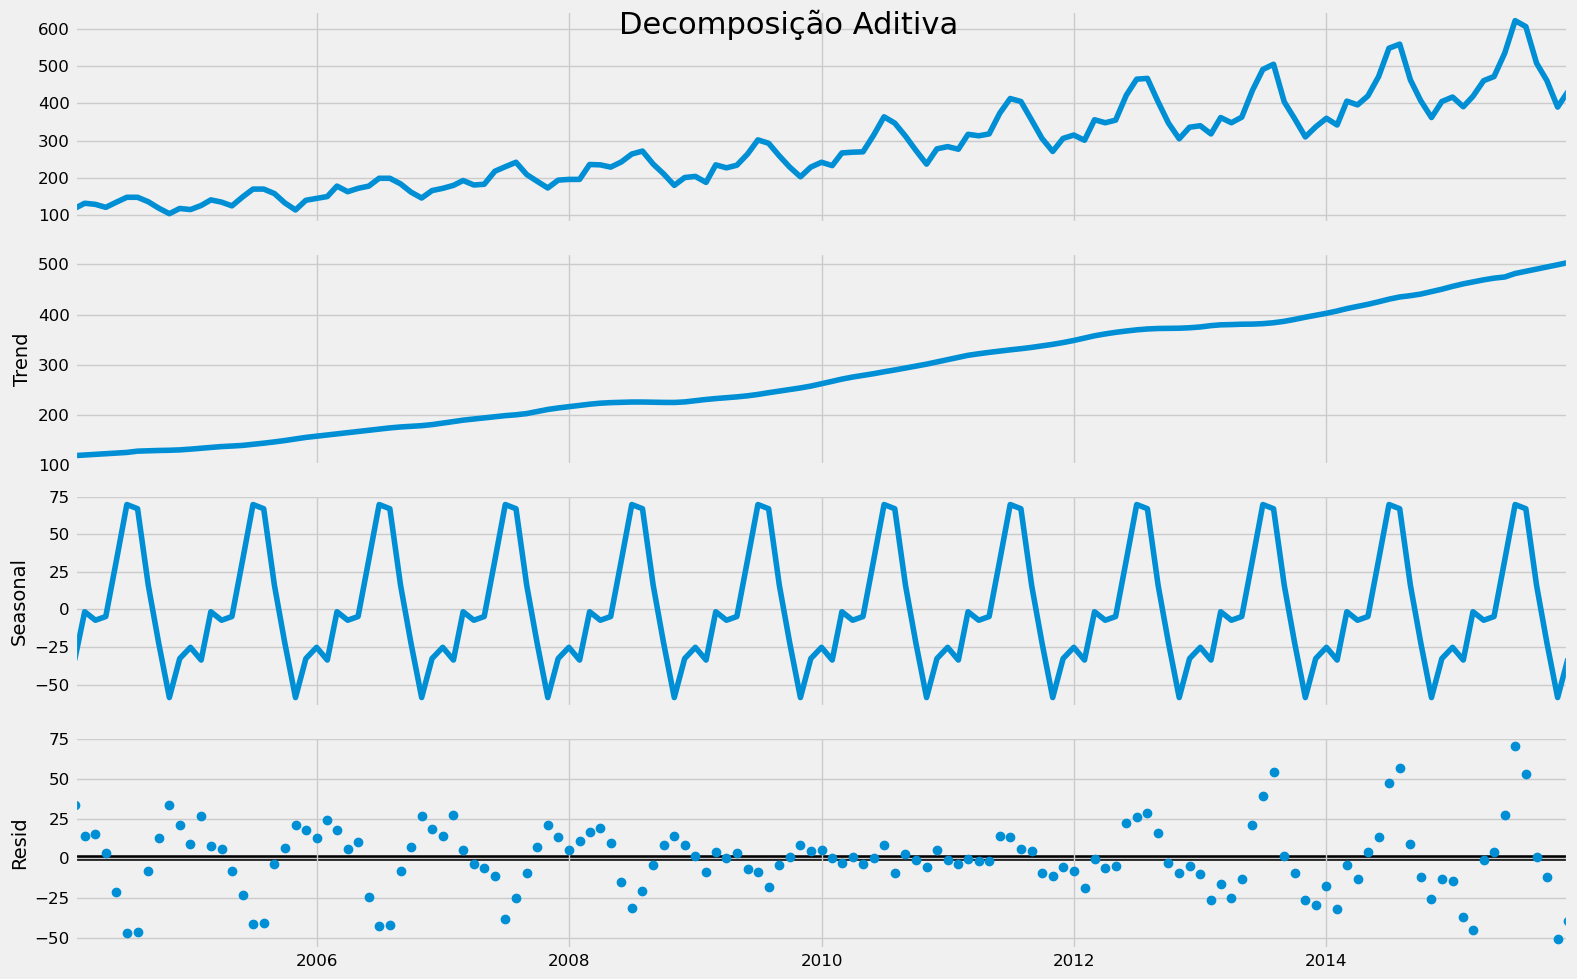

In [106]:
plt.rcParams.update({'figure.figsize': (16, 10)})
decomposicao_aditiva.plot().suptitle('Decomposição Aditiva', fontsize = 22)
plt.show()

In [107]:
dados_serie_reconstruida = pd.concat([decomposicao_multiplicativa.seasonal,
                                      decomposicao_multiplicativa.trend,
                                      decomposicao_multiplicativa.resid,
                                      decomposicao_multiplicativa.observed], axis = 1)

In [108]:
dados_serie_reconstruida.columns = ['Sazonalidade', 'Tendência', 'Resíduos', 'Valores_Observados']

In [109]:
dados_serie_reconstruida.head()

,Sazonalidade,Tendência,Resíduos,Valores_Observados
mes,,,,
2004-02-01,0.891048,118.316336,1.119274,118.0
2004-03-01,1.013066,119.588044,1.089554,132.0
2004-04-01,0.981265,120.859751,1.087731,129.0
2004-05-01,0.979889,122.131459,1.011069,121.0
2004-06-01,1.108635,123.403166,0.986777,135.0


In [110]:
#Valores observados = Sazonalidade * Tendência * Resíduos

In [111]:
rolmean = dados['consumo_energia'].rolling(window=12).mean()
rolstd = dados['consumo_energia'].rolling(window=12).std()

In [112]:
x = dados['mes'].values
y = dados['consumo_energia'].values

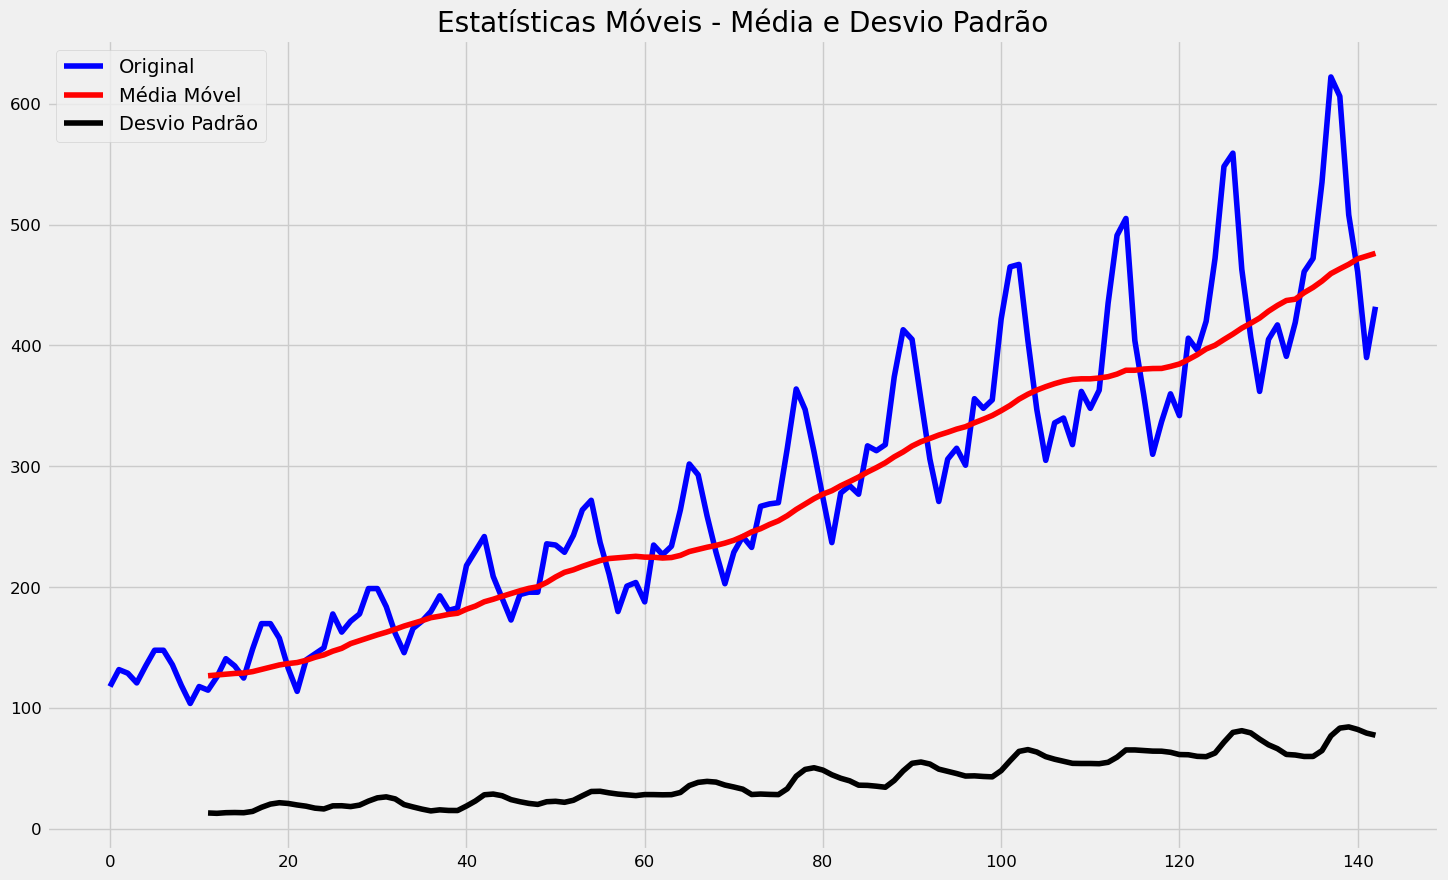

In [113]:
orig = plt.plot(y, color='blue', label='Original')
mean = plt.plot(rolmean, color = 'red', label = 'Média Móvel')
std = plt.plot(rolstd, color = 'black', label = 'Desvio Padrão')
plt.legend(loc = 'best')
plt.title('Estatísticas Móveis - Média e Desvio Padrão')
plt.show()

In [114]:
dfteste = adfuller(dados_serie.consumo_energia, autolag = 'AIC')

dfsaida = pd.Series(dfteste[0:4], index = ['Estatística do Teste',
                                           'Valor-p',
                                           'Número de Lags Considerados',
                                           'Número de Observações Usadas'])

for key, values in dfteste[4].items():
    dfsaida['Valor Crítico (%s)' %key] = values

print(dfsaida)

Estatística do Teste              0.794483
Valor-p                           0.991547
Número de Lags Considerados      13.000000
Número de Observações Usadas    129.000000
Valor Crítico (1%)               -3.482088
Valor Crítico (5%)               -2.884219
Valor Crítico (10%)              -2.578864
dtype: float64


In [115]:
dados['consumo_energia_log'] = np.log(dados['consumo_energia'])
dados.head()

,mes,consumo_energia,consumo_energia_log
0,2004-02-01,118,4.770685
1,2004-03-01,132,4.882802
2,2004-04-01,129,4.859812
3,2004-05-01,121,4.795791
4,2004-06-01,135,4.905275


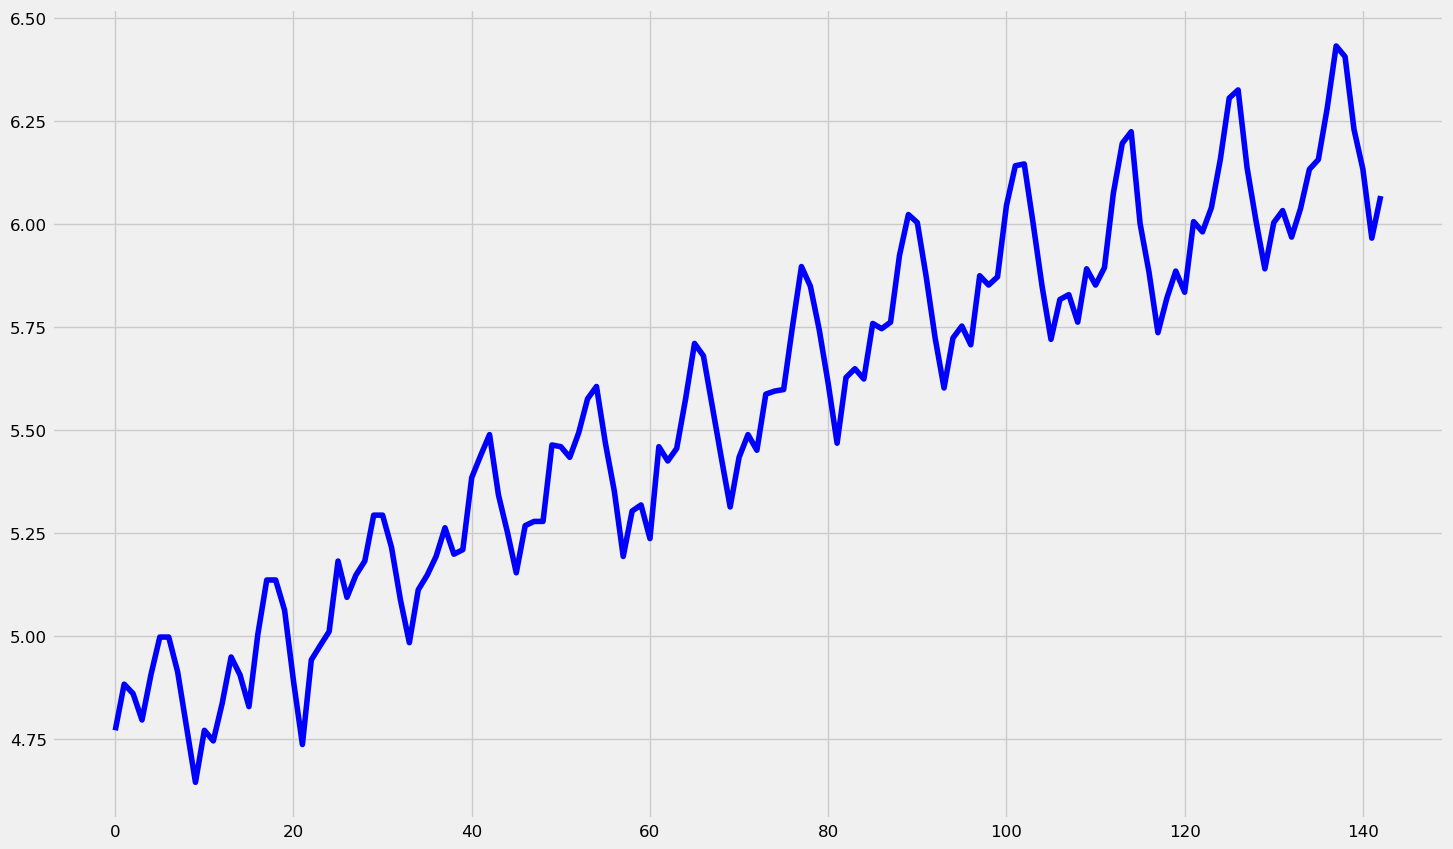

In [116]:
plt.plot(dados['consumo_energia_log'], color = "blue") 

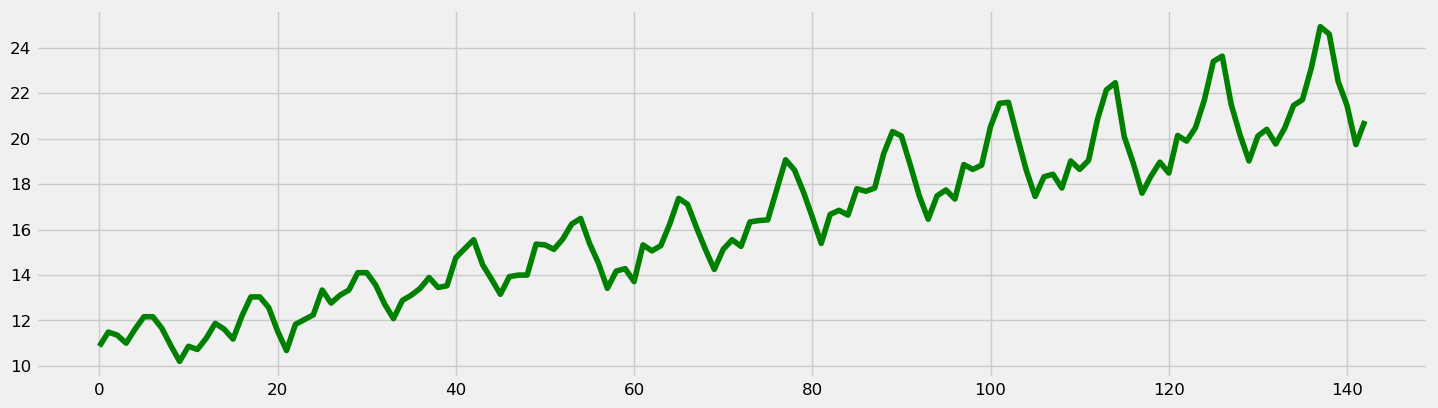

In [117]:
daods_sqrt = np.sqrt(dados['consumo_energia'])

plt.subplot(211)
plt.plot(daods_sqrt, color = 'green')

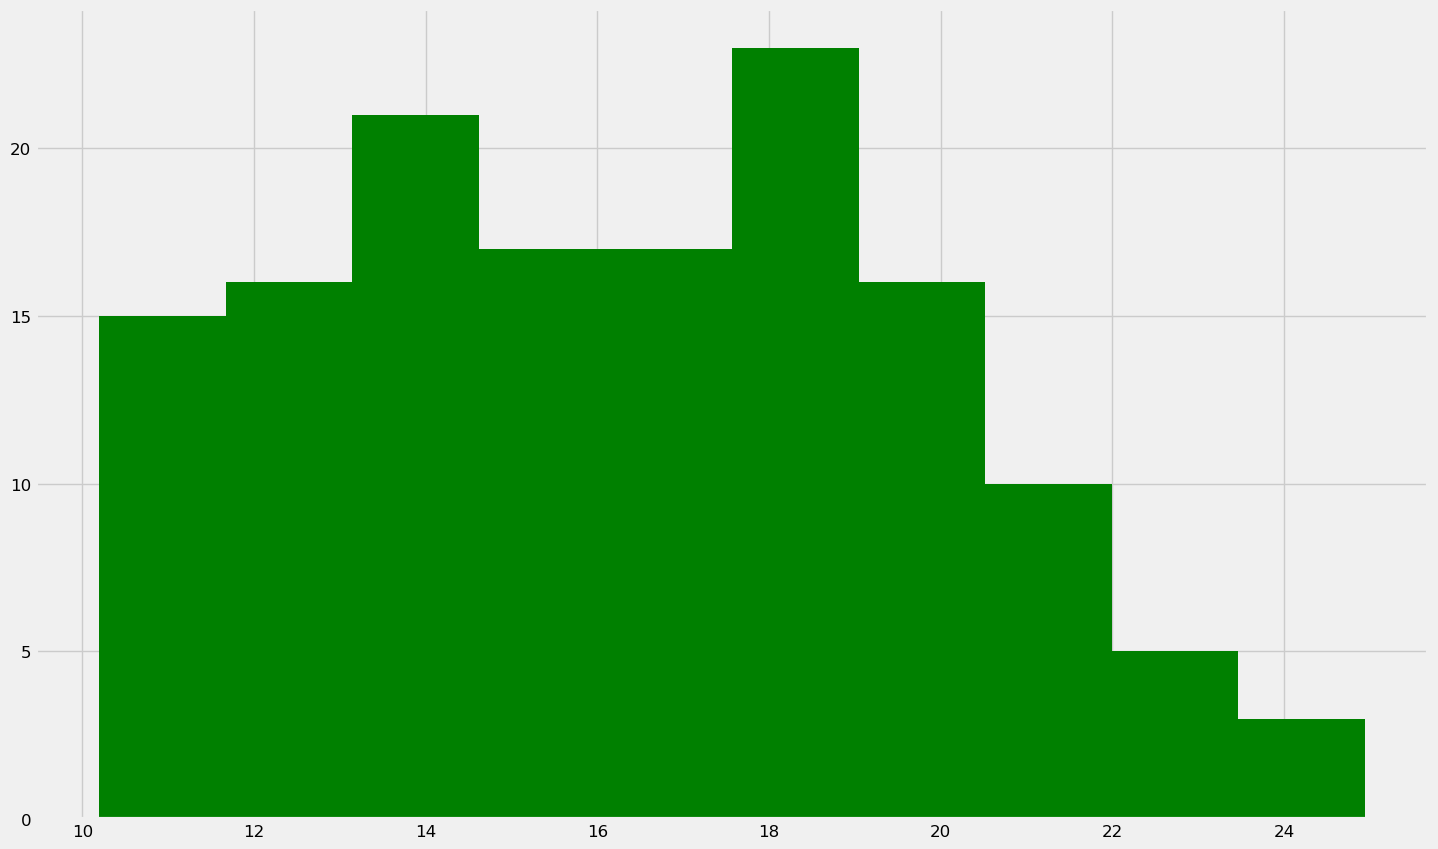

In [118]:
plt.hist(daods_sqrt, color = 'green')
plt.show()

In [119]:
df_serie = dados_serie.copy()

In [120]:
dados_serie['consumo_energia_serie_suavizada'] = dados_serie.rolling(window = 12).mean()

In [121]:
dados_serie

,consumo_energia,consumo_energia_serie_suavizada
mes,,
2004-02-01,118,NaN
2004-03-01,132,NaN
2004-04-01,129,NaN
2004-05-01,121,NaN
2004-06-01,135,NaN
...,...,...
2015-08-01,606,463.333333
2015-09-01,508,467.083333
2015-10-01,461,471.583333


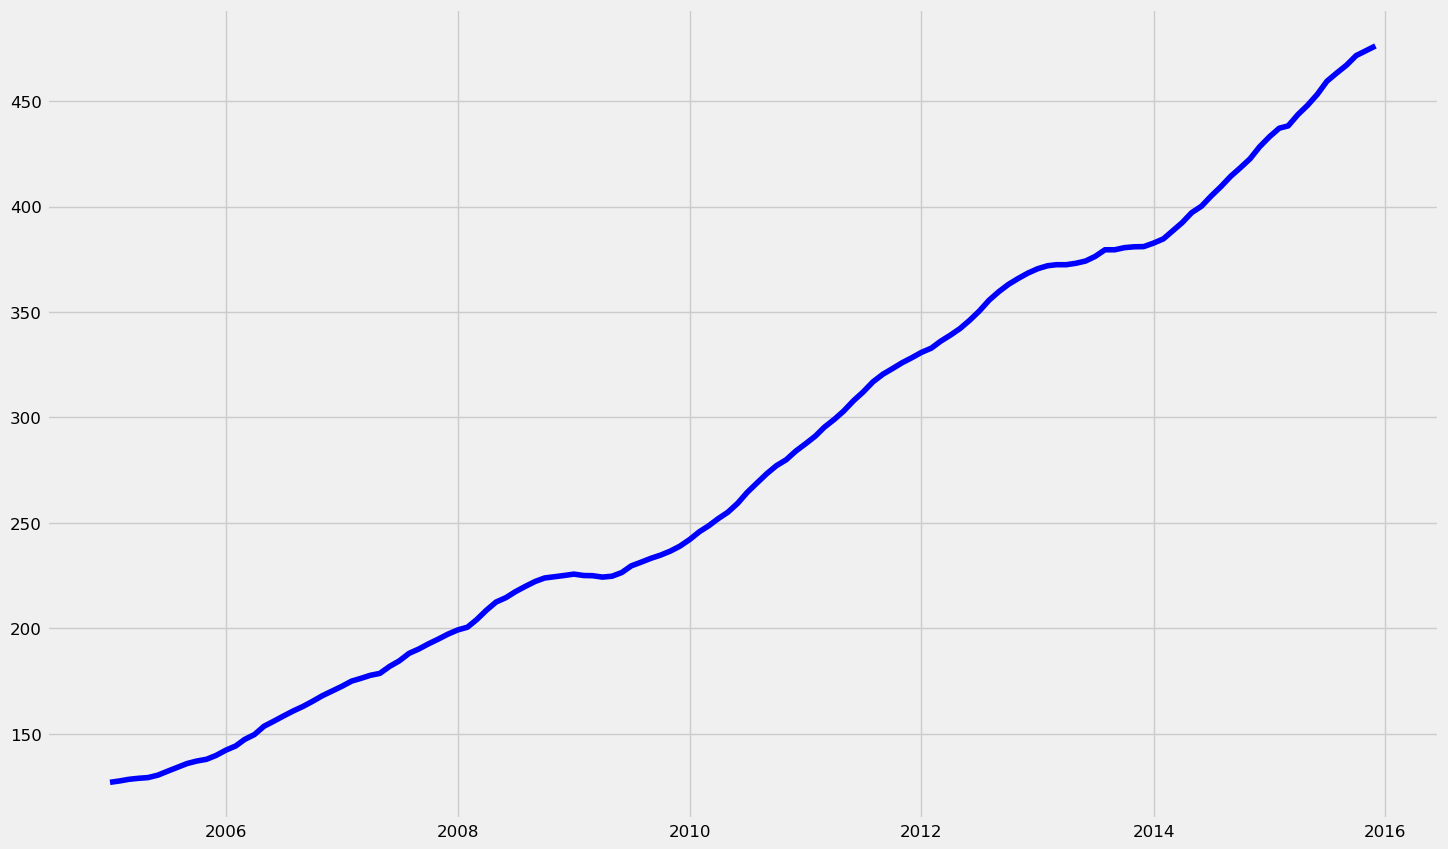

In [122]:
plt.plot(dados_serie['consumo_energia_serie_suavizada'], color='blue')

In [123]:
serie_suavizada_exp = df_serie.ewm(alpha=0.2, adjust=True).mean()

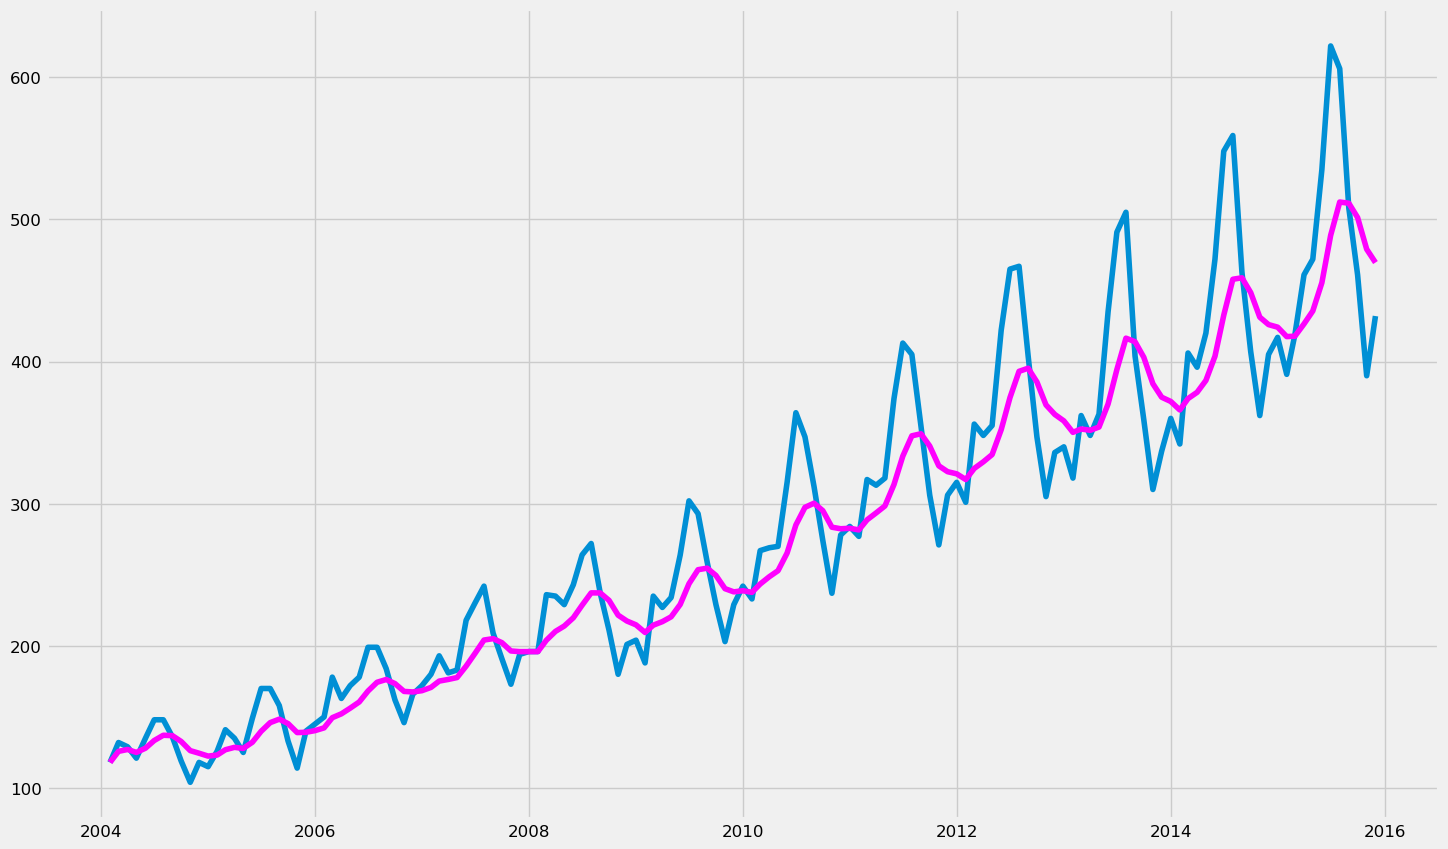

In [124]:
plt.plot(df_serie)
plt.plot(serie_suavizada_exp, color = 'magenta')